# Seminar 1 — Wi-Fi Performance Prediction with Linear Regression

This notebook implements a multi-variable linear regression model to predict the performance of Wi-Fi deployments using the `dataset_Seminar1.txt` dataset.

**Structure:**
- **Part I** — Data preparation & analysis
- **Part II** — Model implementation & evaluation

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATASET_PATH = 'dataset_Seminar1.txt'
RANDOM_STATE = 42
TEST_SIZE    = 0.20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


---
## Part I — Data Preparation & Analysis

### 1.1 Load the dataset

In [11]:
# Column names inferred from Wi-Fi simulation context
COLUMN_NAMES = [
    'n_stations',        # Number of stations in the STAs
    'Load',         # Supported data rate (bps)
    'Siex(x)',           # Wi-Fi channel number
    'Size(y)',             # Number of access points
    'Area',       # Total number of active flows
    'cw_size',           # Contention window size
    'channel_width',     # Channel width
    'packet_size',
    'MAX RSSI',     # Channel bandwidth (MHz): 40 / 80 / 160
    'AVG RSSI',      # Payload size (bytes)
    'MIN RSSI',    # Maximum achievable throughput (bps)
    'Prob_of_failure', # Actual measured throughput (bps)
    'Throughput',   # Normalised spectral efficiency
    'Average_delay',
    'Total_airtime',
    'Proportional_airtime'
]

df = pd.read_csv(DATASET_PATH, sep=r'\s+', header=None, names=COLUMN_NAMES)

print(f'Shape : {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape : (100000, 16)
Columns: ['n_stations', 'Load', 'Siex(x)', 'Size(y)', 'Area', 'cw_size', 'channel_width', 'packet_size', 'MAX RSSI', 'AVG RSSI', 'MIN RSSI', 'Prob_of_failure', 'Throughput', 'Average_delay', 'Total_airtime', 'Proportional_airtime']


,n_stations,Load,Siex(x),Size(y),Area,cw_size,channel_width,packet_size,MAX RSSI,AVG RSSI,MIN RSSI,Prob_of_failure,Throughput,Average_delay,Total_airtime,Proportional_airtime
0,40.0,60000000.0,22.0,39.0,858.0,63.0,80.0,4000.0,-42.928330,-63.163012,-74.965338,0.415189,7.208644e+06,1.229466e+07,1.084041,0.875490
1,35.0,52500000.0,20.0,33.0,660.0,31.0,40.0,10000.0,-47.815800,-63.298410,-72.847989,0.485311,1.545116e+07,1.275042e+07,1.111263,0.873785
2,16.0,12000000.0,34.0,14.0,476.0,255.0,40.0,4000.0,-46.138494,-60.076333,-70.044800,0.099413,6.743660e+06,2.251690e+06,0.880036,0.849701
3,37.0,18500000.0,35.0,7.0,245.0,31.0,80.0,10000.0,-42.708813,-60.141393,-72.029643,0.493704,1.675025e+07,1.211374e+07,1.126341,0.860103
4,18.0,4500000.0,36.0,35.0,1260.0,127.0,160.0,8000.0,-45.492991,-63.780783,-76.225550,0.011664,4.500000e+06,1.446000e-03,0.276770,0.275687


### 1.2 Feature statistics (mean & standard deviation)

In [12]:
stats = df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats.columns = ['Mean', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max']
print('=== Feature Statistics ===')
display(stats.style.format('{:.4f}'))

=== Feature Statistics ===


,Mean,Std Dev,Min,Q1,Median,Q3,Max
n_stations,21.4462,11.5544,2.0000,11.0000,21.0000,31.0000,41.0000
Load,21402920.0000,18520420.5347,500000.0000,7250000.0000,16000000.0000,30000000.0000,82000000.0000
Siex(x),20.5629,11.5452,1.0000,11.0000,21.0000,31.0000,40.0000
Size(y),20.4796,11.5406,1.0000,11.0000,20.0000,30.0000,40.0000
Area,421.2704,360.3443,1.0000,120.0000,320.0000,640.0000,1600.0000
cw_size,227.0439,323.3509,3.0000,15.0000,63.0000,255.0000,1023.0000
channel_width,75.1060,53.7043,20.0000,20.0000,80.0000,160.0000,160.0000
packet_size,7997.5800,2825.5325,4000.0000,6000.0000,8000.0000,10000.0000,12000.0000
MAX RSSI,-45.9112,5.4003,-81.4052,-48.1315,-44.1111,-41.8888,-40.8636
AVG RSSI,-57.5774,6.1085,-81.4052,-61.9850,-58.1632,-53.5895,-40.8660


In [13]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

print('\n=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows found.')

=== Missing Values ===
No missing values found.

=== Duplicate Rows ===
0 duplicate rows found.


### 1.3 Data visualisation

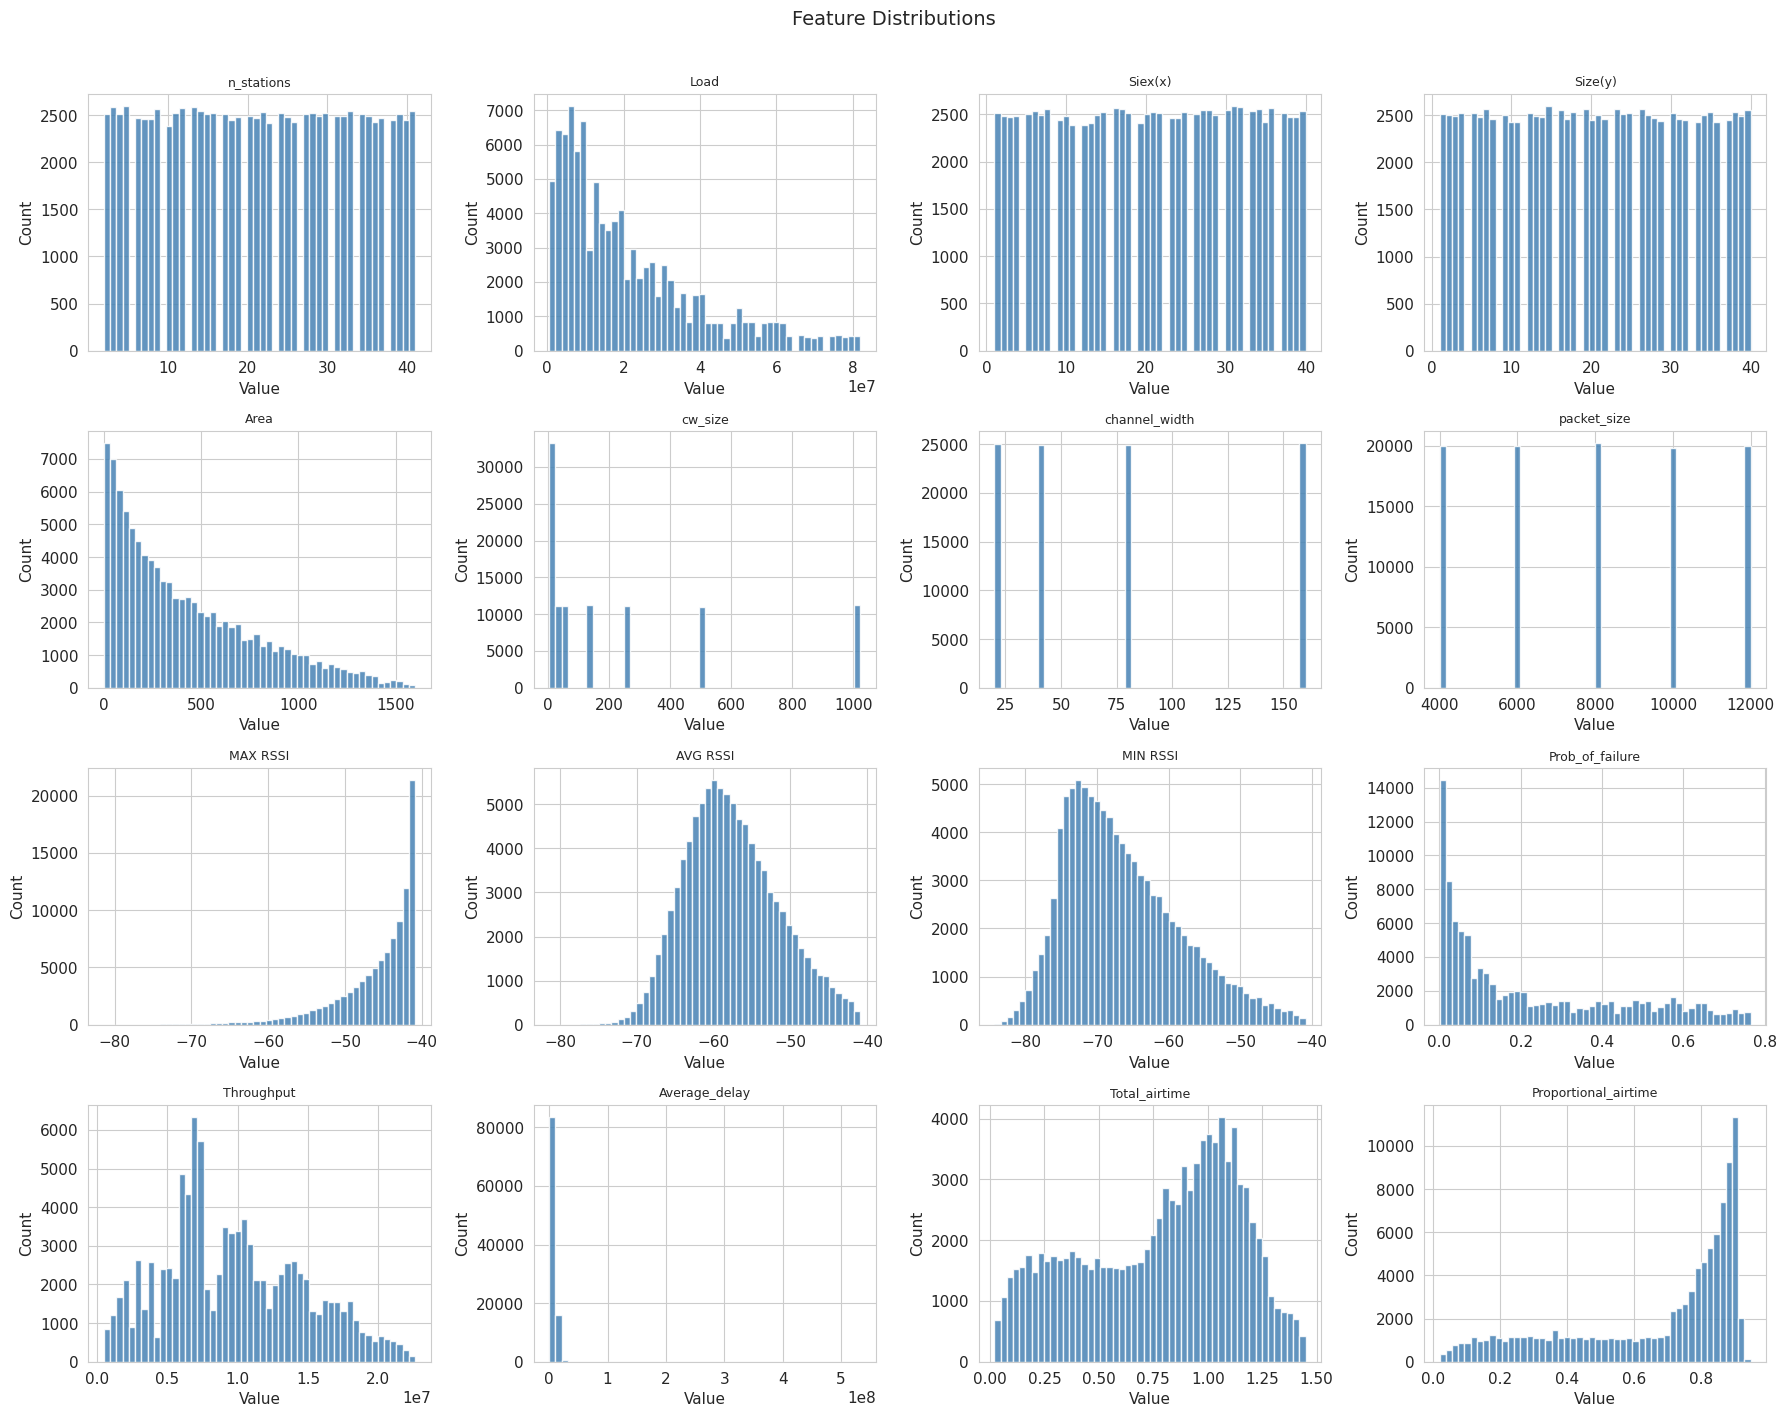

In [14]:
# ── Histograms for every feature ──────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(COLUMN_NAMES):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

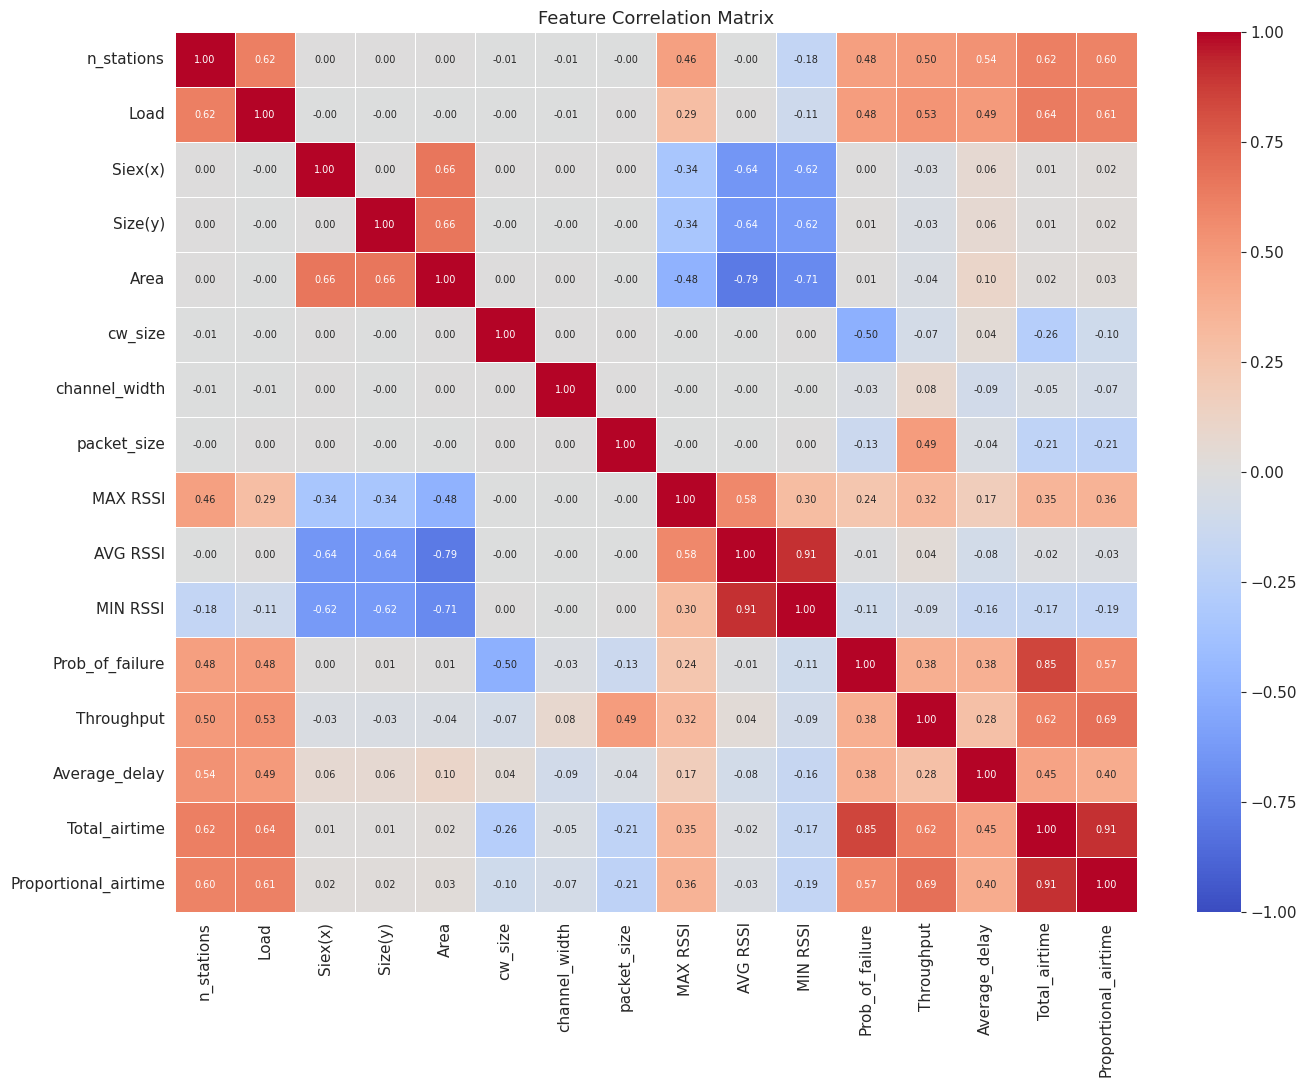

In [19]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 11))
corr = df.corr()
# mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, annot_kws={'size': 7}, vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

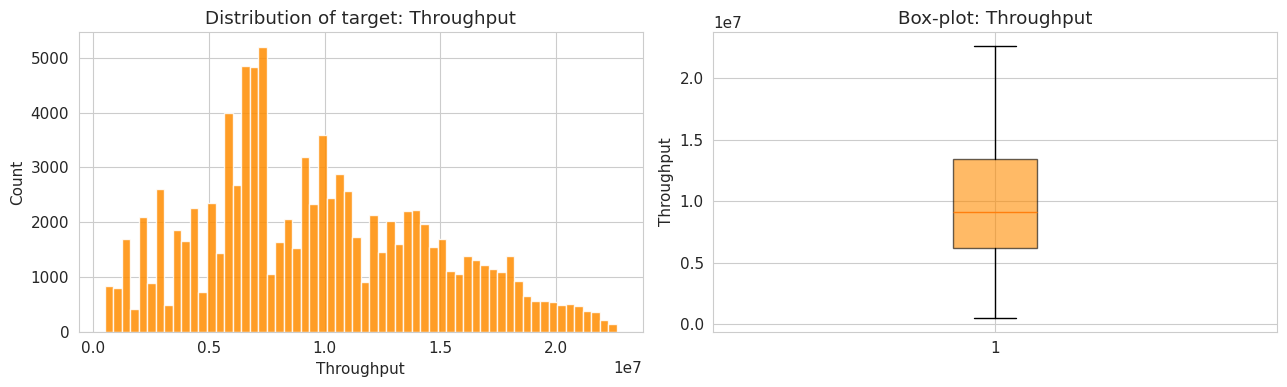

Target mean : 9716009.3602
Target std  : 4958024.8182


In [22]:
# ── Target variable distribution ──────────────────────────────────────────────
TARGET = 'Throughput'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET], bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Distribution of target: {TARGET}')
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Count')

axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor='darkorange', alpha=0.6))
axes[1].set_title(f'Box-plot: {TARGET}')
axes[1].set_ylabel(TARGET)

plt.tight_layout()
plt.show()

print(f"Target mean : {df[TARGET].mean():.4f}")
print(f"Target std  : {df[TARGET].std():.4f}")

Top-6 features correlated with "Throughput":
Proportional_airtime    0.685657
Total_airtime           0.617722
Load                    0.527221
n_stations              0.495302
packet_size             0.490532
Prob_of_failure         0.383904


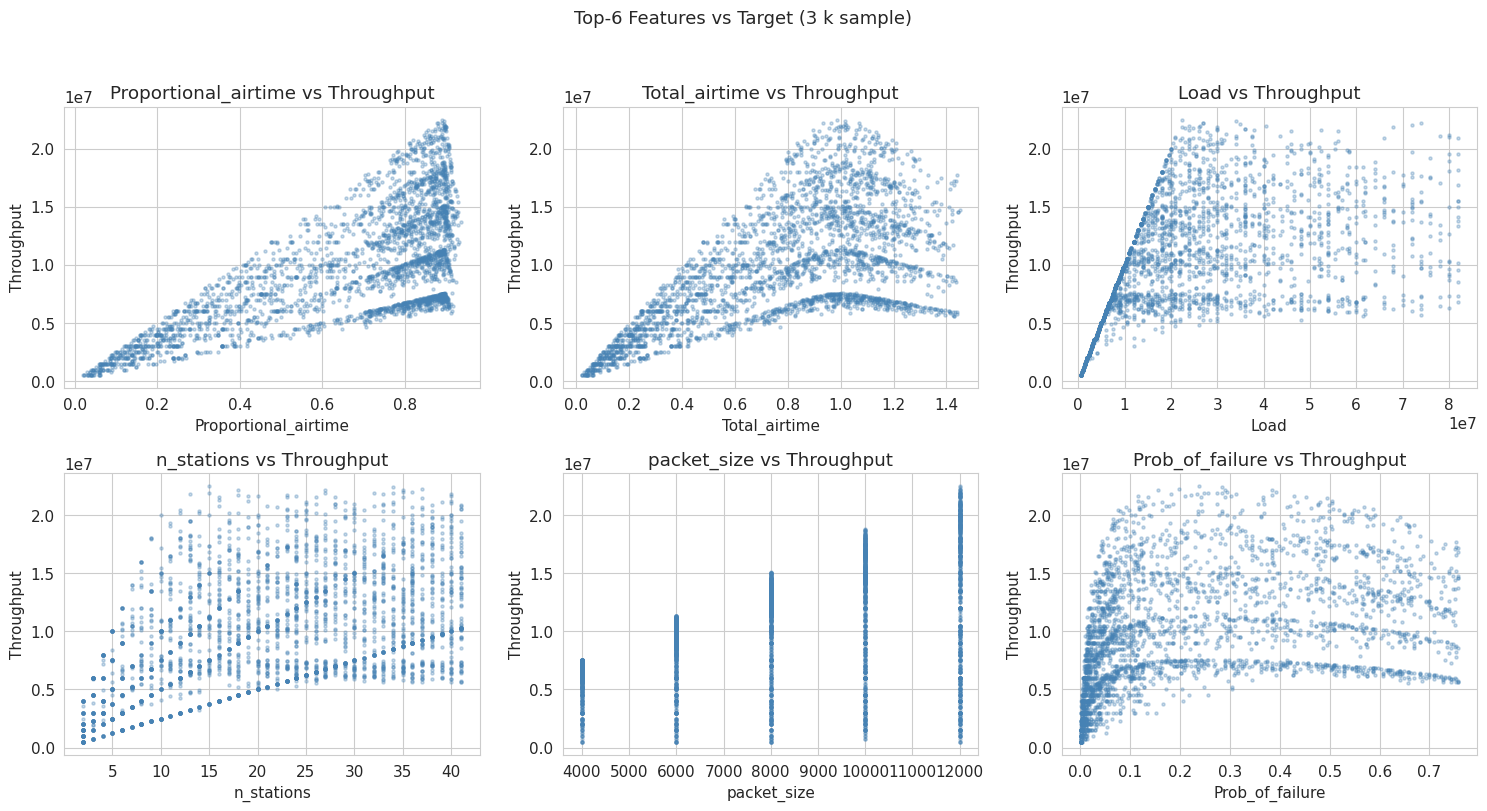

In [23]:
# ── Scatter plots of most-correlated features vs. target ─────────────────────
top_features = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(6).index.tolist()
print(f'Top-6 features correlated with "{TARGET}":')
print(corr[TARGET][top_features].to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sample = df.sample(3000, random_state=RANDOM_STATE)  # subsample for clarity
for i, feat in enumerate(top_features):
    axes[i].scatter(sample[feat], sample[TARGET], alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f'{feat} vs {TARGET}')

plt.suptitle('Top-6 Features vs Target (3 k sample)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.4 Data preprocessing

In [ ]:
# ── Categorical encoding ──────────────────────────────────────────────────────
# channel_width is a discrete categorical-like feature (40, 80, 160 MHz)
print('Unique channel_width values:', df['channel_width'].unique())
df = pd.get_dummies(df, columns=['channel_width'], prefix='bw', drop_first=False)
print('Columns after one-hot encoding channel_width:', [c for c in df.columns if 'bw_' in c])

In [ ]:
# ── Feature / target split ────────────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c != TARGET]
X = df[FEATURE_COLS].values.astype(np.float64)
y = df[TARGET].values.astype(np.float64)

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')

### 1.5 Train / test split (80 % / 20 %)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Training set   : {X_train.shape[0]:,} samples ({100*(1-TEST_SIZE):.0f}%)')
print(f'Test set       : {X_test.shape[0]:,} samples ({100*TEST_SIZE:.0f}%)')

In [ ]:
# ── Standardisation (Z-score normalisation) ───────────────────────────────────
# Fit ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Normalisation complete.')
print(f'Train mean (first 5 features): {X_train_s[:, :5].mean(axis=0).round(4)}')
print(f'Train std  (first 5 features): {X_train_s[:, :5].std(axis=0).round(4)}')

---
## Part II — Model Implementation & Evaluation

### 2.1 Manual multi-variable linear regression (Gradient Descent)

In [ ]:
class LinearRegressionGD:
    """
    Multi-variable linear regression trained with batch gradient descent.
    Uses Mean Squared Error (MSE) as the loss function.
    """

    def __init__(self, learning_rate=0.01, n_iterations=500):
        self.lr          = learning_rate
        self.n_iters     = n_iterations
        self.weights_    = None
        self.bias_       = None
        self.train_loss_ = []

    # ── Prediction ─────────────────────────────────────────────────────────────
    def predict(self, X):
        return X @ self.weights_ + self.bias_

    # ── MSE loss ───────────────────────────────────────────────────────────────
    @staticmethod
    def mse(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    # ── Gradient descent fit ───────────────────────────────────────────────────
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights_ = np.zeros(n_features)
        self.bias_    = 0.0
        self.train_loss_ = []

        for iteration in range(self.n_iters):
            y_pred  = self.predict(X)
            error   = y_pred - y

            # Gradient of MSE w.r.t. weights and bias
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * error.sum()

            self.weights_ -= self.lr * dw
            self.bias_    -= self.lr * db

            loss = self.mse(y, self.predict(X))
            self.train_loss_.append(loss)

            if (iteration + 1) % 100 == 0:
                print(f'  Iteration {iteration+1:>4d}/{self.n_iters}  |  MSE = {loss:.6f}')

        return self

### 2.2 Fit the model

In [ ]:
print('=== Training — Gradient Descent Linear Regression ===')
gd_model = LinearRegressionGD(learning_rate=0.05, n_iterations=500)
gd_model.fit(X_train_s, y_train)

print(f'\nFinal training MSE : {gd_model.train_loss_[-1]:.6f}')

In [ ]:
# Also fit sklearn's closed-form OLS for comparison
ols_model = LinearRegression()
ols_model.fit(X_train_s, y_train)
print('sklearn OLS model fitted.')

### 2.3 Model evaluation

In [ ]:
def evaluate(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'  MSE  : {mse:.6f}')
    print(f'  RMSE : {rmse:.6f}')
    print(f'  MAE  : {mae:.6f}')
    print(f'  R²   : {r2:.6f}')
    return dict(MSE=mse, RMSE=rmse, MAE=mae, R2=r2)

# Gradient Descent model
y_pred_gd_train = gd_model.predict(X_train_s)
y_pred_gd_test  = gd_model.predict(X_test_s)

# sklearn OLS model
y_pred_ols_train = ols_model.predict(X_train_s)
y_pred_ols_test  = ols_model.predict(X_test_s)

print('=== Gradient Descent Model ===')
gd_train_metrics = evaluate('Train', y_train, y_pred_gd_train)
gd_test_metrics  = evaluate('Test ', y_test,  y_pred_gd_test)

print('\n=== sklearn OLS (closed-form) ===')
ols_train_metrics = evaluate('Train', y_train, y_pred_ols_train)
ols_test_metrics  = evaluate('Test ', y_test,  y_pred_ols_test)

### 2.4 Coefficient analysis

In [ ]:
feature_names = FEATURE_COLS
coef_df = pd.DataFrame({
    'Feature'   : feature_names,
    'GD Coeff'  : gd_model.weights_,
    'OLS Coeff' : ols_model.coef_,
}).sort_values('OLS Coeff', key=abs, ascending=False)

print('=== Top-10 Coefficients by Magnitude (OLS) ===')
display(coef_df.head(10).reset_index(drop=True))

# Bar chart of OLS coefficients
plt.figure(figsize=(13, 5))
colors = ['steelblue' if c >= 0 else 'coral' for c in coef_df['OLS Coeff']]
plt.bar(range(len(coef_df)), coef_df['OLS Coeff'], color=colors)
plt.xticks(range(len(coef_df)), coef_df['Feature'], rotation=45, ha='right', fontsize=9)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('OLS Regression Coefficients (standardised features)')
plt.ylabel('Coefficient value')
plt.tight_layout()
plt.show()

### 2.5 Training loss curve

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(gd_model.train_loss_, color='steelblue', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent — Training Loss Curve')
plt.tight_layout()
plt.show()

### 2.6 Prediction visualisation (test set)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Gradient Descent', y_pred_gd_test),
    ('OLS (sklearn)',    y_pred_ols_test)
]):
    ax.scatter(y_test, y_pred, alpha=0.15, s=4, color='steelblue')
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name} — Actual vs Predicted (test set)')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Residual distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Gradient Descent', y_pred_gd_test),
    ('OLS (sklearn)',    y_pred_ols_test)
]):
    residuals = y_test - y_pred
    ax.hist(residuals, bins=80, color='darkorange', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Residual (actual − predicted)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Residual distribution')

plt.tight_layout()
plt.show()

### 2.7 Metrics summary

In [ ]:
summary = pd.DataFrame({
    'Model'   : ['GD Linear Reg. (train)', 'GD Linear Reg. (test)',
                 'OLS sklearn (train)',    'OLS sklearn (test)'],
    'MSE'     : [gd_train_metrics['MSE'],  gd_test_metrics['MSE'],
                 ols_train_metrics['MSE'], ols_test_metrics['MSE']],
    'RMSE'    : [gd_train_metrics['RMSE'], gd_test_metrics['RMSE'],
                 ols_train_metrics['RMSE'],ols_test_metrics['RMSE']],
    'MAE'     : [gd_train_metrics['MAE'],  gd_test_metrics['MAE'],
                 ols_train_metrics['MAE'], ols_test_metrics['MAE']],
    'R²'      : [gd_train_metrics['R2'],   gd_test_metrics['R2'],
                 ols_train_metrics['R2'],  ols_test_metrics['R2']],
})
display(summary.set_index('Model').style.format('{:.6f}'))